File to visualize the label and graph

In [146]:
from pathlib import Path
import nibabel as nib
import json
import matplotlib.pyplot as plt
from data.visualizations import visualize_3d_matrices
import pprint
import numpy as np

In [147]:
label_graph_folder = Path("label_graph/")
graph_fp = label_graph_folder / "00328c.graph.json"
label_fp = label_graph_folder / "00328c.label.nii.gz"

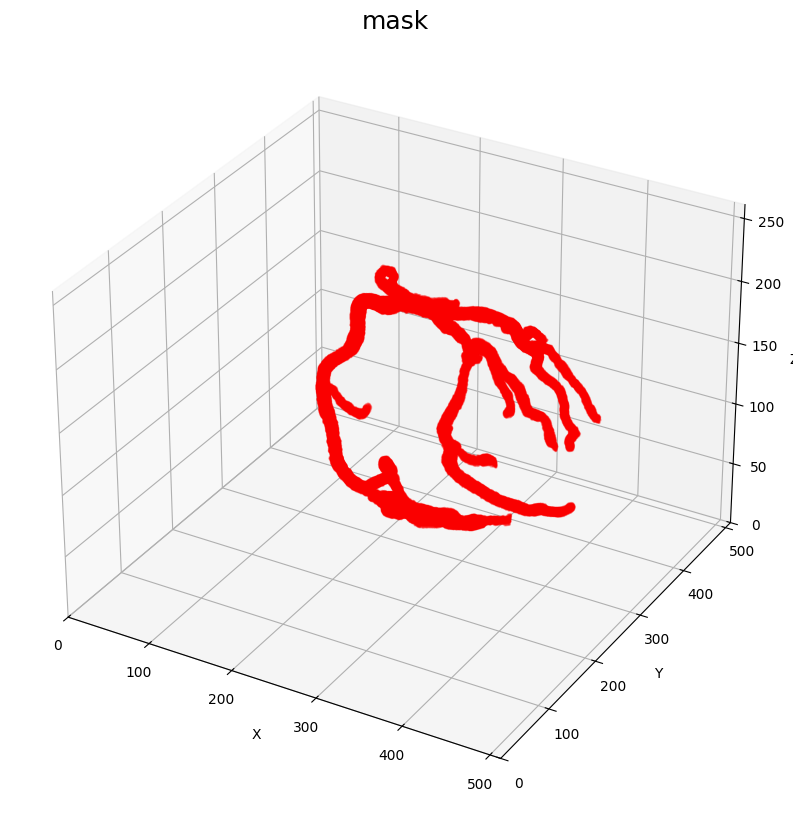

In [148]:
# Let's start with the mask
mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

visualize_3d_matrices(matrices=[mask_matrice], titles=["mask"])

In [149]:
# now the graph
with open(graph_fp, "r") as file:
    data = json.load(file)

pprint.pp(data["edges"])

[{'length': 45.555038631672225,
  'skeletons': [[-3.9306640625, 149.6103515625, -255.54998779296875],
                [-6.126192249041056, 149.9599770429464, -258.04998779296875],
                [-8.14768095468244, 151.59885282968244, -259.00876075463884],
                [-10.283266892278974, 153.416079392279, -259.6384502387676],
                [-12.042070778520191, 155.4932426535202, -260.30305196216773],
                [-13.879228167310293, 157.270957967176, -261.04998779296875],
                [-15.881907363569796, 158.8194203219174, -262.0133105071458],
                [-18.09720079118183, 159.92551012955806, -263.04998779296875],
                [-20.317997051971894, 160.76020554989023, -263.7871488071087],
                [-21.973209699622256, 162.24078782462226, -264.54998779296875],
                [-23.522207272858633, 163.79071705338518, -265.2775211090338],
                [-24.75324306631261, 165.97589931631262, -266.25293395846586],
                [-25.2983951599041

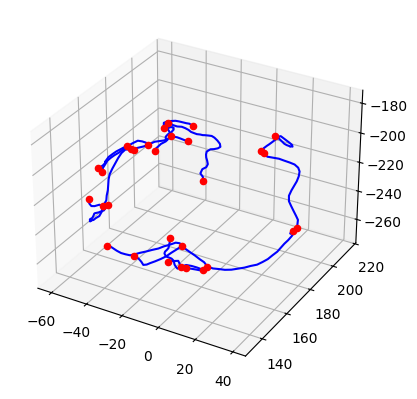

In [150]:
# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for node in data["nodes"]:
    [x, y, z] = node["pos"]
    ax.scatter(x, y, z, c="r")

for edge in data["edges"]:
    # length = edge["length"]
    # source = edge["source"]
    # target = edge["target"]

    skeletons = edge["skeletons"]
    xs, ys, zs = zip(*skeletons) # this is all we plot
    ax.plot(xs, ys, zs, c="b")

# get the np array from the plot
plt.show()

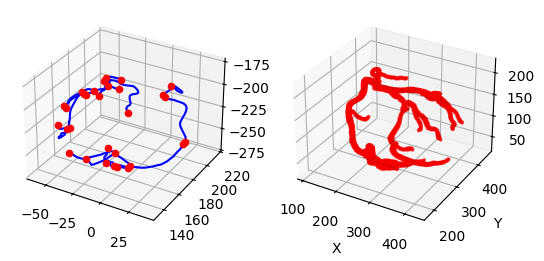

In [151]:
# let's plot them next to each other
def plot_graph_and_matrice(graph_data, mask_matrice):
    fig = plt.figure()
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    for node in graph_data["nodes"]:
        [x, y, z] = node["pos"]
        ax1.scatter(x, y, z, c="r")

    for edge in graph_data["edges"]:
        # length = edge["length"]
        # source = edge["source"]
        # target = edge["target"]

        skeletons = edge.get("skeletons")

        if skeletons is None:
            # print("Edge without skeletons")
            # we still plot the connection between the nodes
            source = edge["source"]
            target = edge["target"]
            source_pos = graph_data["nodes"][source]["pos"]
            target_pos = graph_data["nodes"][target]["pos"]
            xs, ys, zs = zip(source_pos, target_pos)
            ax1.plot(xs, ys, zs, c="b")
        else:
            xs, ys, zs = zip(*skeletons) # this is all we plot
            ax1.plot(xs, ys, zs, c="b")

    x, y, z = np.where(mask_matrice == 1)
    ax2.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.2)

    # Set labels even if we don't show them
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    plt.show()

plot_graph_and_matrice(graph_data=data, mask_matrice=mask_matrice)

Okay this is more complex than it looks like. We need to analyze this.

In [152]:
# We know that the graph is in the same space as the mask
# however they define the space differently. Rotation, and distances are different.

# Let's try to align them

# let's get the the header data from the nib file
mask_header = mask.header
print(mask_header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 512 512 261   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.          0.31835938  0.31835938  0.5         1.          1.
  1.          1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 75.34082
qoffset_y       : 74.15918
qo

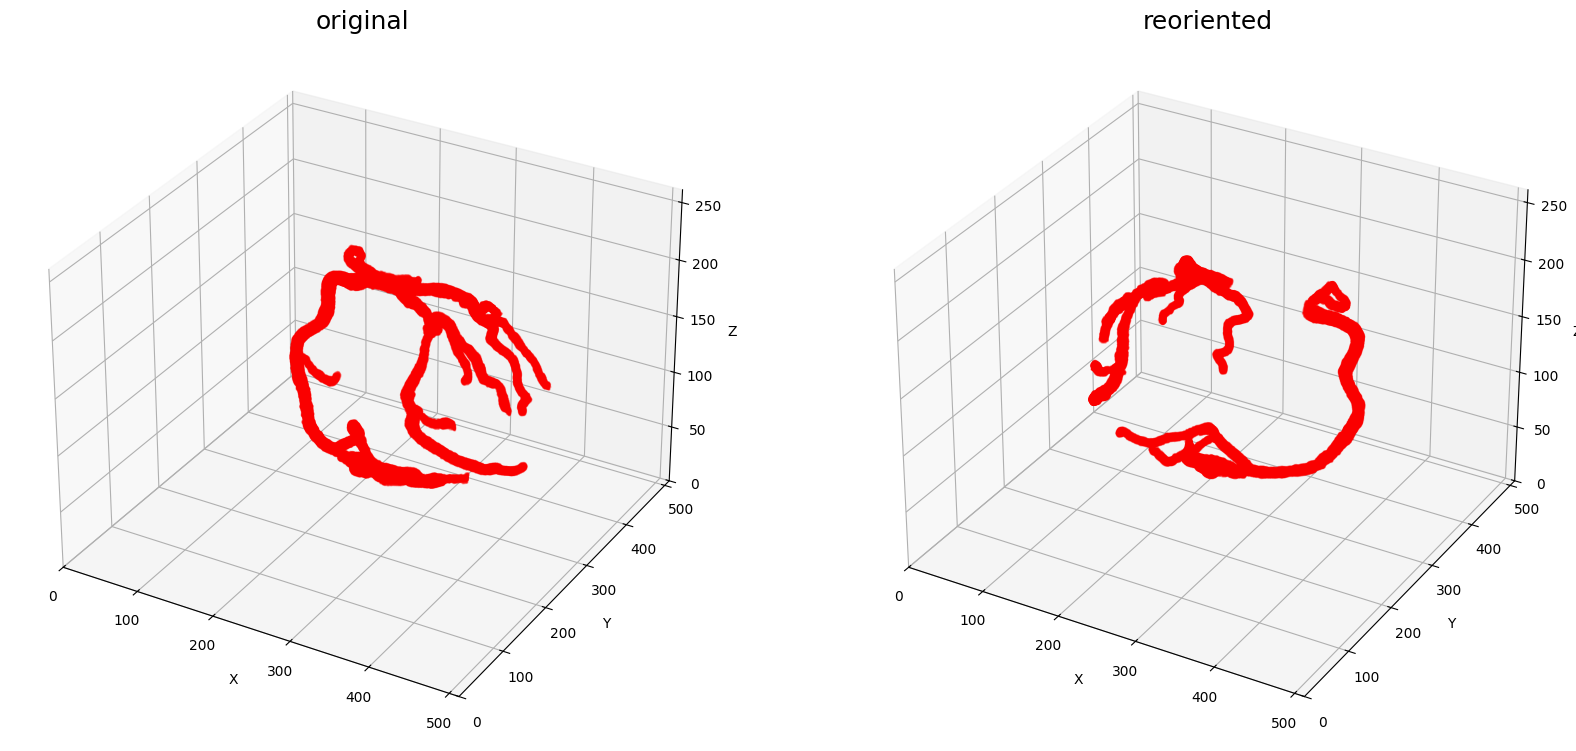

In [153]:
# we need a function that calculates distances between two points in the mask label
# This function has multiple steps: 1. Reorientation
ras_mask = nib.as_closest_canonical(mask)
ras_mask_matrice = ras_mask.get_fdata()

visualize_3d_matrices(matrices=[mask_matrice, ras_mask_matrice], titles=["original", "reoriented"])


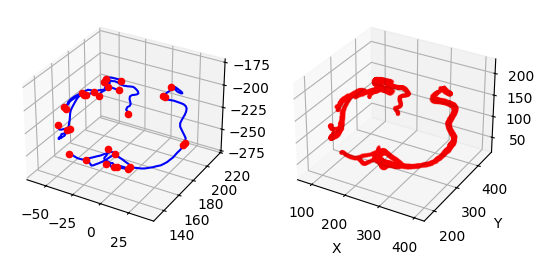

In [154]:
plot_graph_and_matrice(data, ras_mask_matrice)

In [155]:
print(f"non transformed affine mask: {mask.affine}")
print(f"rotated affine mask: {ras_mask.affine}")

non transformed affine mask: [[  -0.31835938    0.            0.           75.34082031]
 [  -0.            0.31835938    0.           74.15917969]
 [   0.           -0.            0.5        -285.54998779]
 [   0.            0.            0.            1.        ]]
rotated affine mask: [[   0.31835938    0.            0.          -87.34082031]
 [   0.            0.31835938    0.           74.15917969]
 [   0.            0.            0.5        -285.54998779]
 [   0.            0.            0.            1.        ]]


[262. 237.  60.]


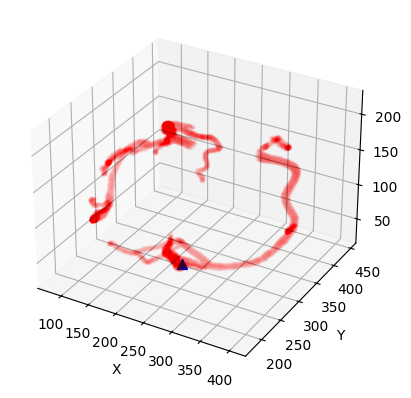

In [156]:
# okay seems like we now know how to transform it, we use the affine matrix. 
# This is computationally heavy, let's first do a sanity test. Let's take a point from the graph and plot it in the mask.

# x, y, z = [-3.9306640625, 149.6103515625, -255.54998779296875]
node_coords = np.array([-3.9306640625, 149.6103515625, -255.54998779296875, 1])
voxel_coords = np.linalg.inv(ras_mask.affine) @ node_coords
voxel_coords = voxel_coords[:3]
print(voxel_coords)

x, y, z = np.where(ras_mask_matrice == 1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.05)
ax.scatter(voxel_coords[0], voxel_coords[1], voxel_coords[2], c='blue', marker='^', s=50, alpha=1.0)

# Set labels even if we don't show them
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

We now know how to align the data from the voxels to RTS coordinates. Next step is actually getting a graph.

In [157]:
from skimage.morphology import skeletonize

skeleton = skeletonize(ras_mask_matrice)

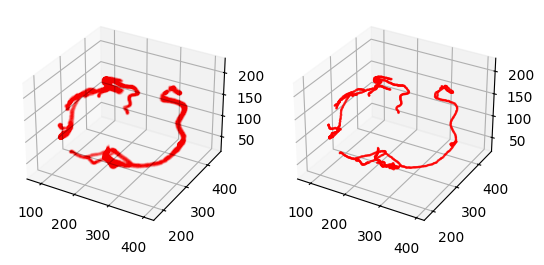

In [158]:
# let's visualize the skeleton
fig = plt.figure()

ax1 = fig.add_subplot(121, projection='3d')

x, y, z = np.where(ras_mask_matrice == 1)
ax1.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.05)

ax2 = fig.add_subplot(122, projection='3d')

x, y, z = np.where(skeleton == 1)
ax2.scatter(x, y, z, c='red', marker='o', s=0.5, alpha=0.5)

plt.show()

In [159]:
def plot_networkx_graph(graph_data, title):
    plt.figure()
    ax = plt.subplot(111, projection='3d')

    for node_id in graph_data.nodes:
        pos = graph_data.nodes[node_id]['pts'][0].tolist()
        ax.scatter(pos[0], pos[1], pos[2], c='r')
    
    for (s, e) in graph_data.edges():
        ps = graph_data[s][e]['pts']
        ax.plot(ps[:, 0], ps[:, 1], ps[:, 2], c='b')

    plt.title(title)
    plt.show()

Graph with 67 nodes and 77 edges


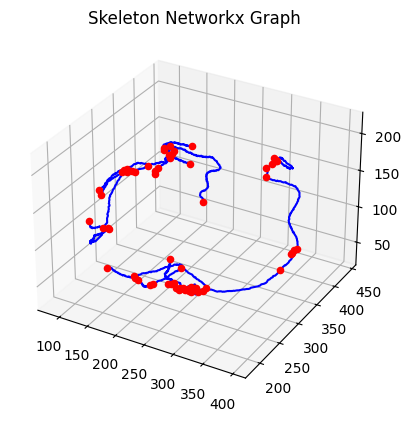

In [160]:
import sknw

snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)
print(snkw_graph)

# let's plot the graph
plot_networkx_graph(snkw_graph, "Skeleton Networkx Graph")

In [161]:
pprint.pp(data)

{'directed': True,
 'multigraph': False,
 'graph': {'coordinateSystem': 'RAS'},
 'nodes': [{'pos': [-3.9306640625, 149.6103515625, -255.54998779296875],
            'is_root': False,
            'id': 1},
           {'pos': [39.3662109375, 178.5810546875, -235.54998779296875],
            'is_root': False,
            'id': 2},
           {'pos': [16.4443359375, 185.2666015625, -198.54998779296875],
            'is_root': True,
            'id': 4},
           {'pos': [-27.8076171875, 158.2060546875, -188.54998779296875],
            'is_root': False,
            'id': 5},
           {'pos': [5.3017578125, 153.7490234375, -257.54998779296875],
            'is_root': False,
            'id': 7},
           {'pos': [-38.6318359375, 157.2509765625, -192.54998779296875],
            'is_root': False,
            'id': 8},
           {'pos': [-3.9306640625, 150.5654296875, -242.04998779296875],
            'is_root': False,
            'id': 9},
           {'pos': [-35.4482421875, 180.49121

In [162]:
# https://networkx.org/documentation/stable/reference/readwrite/generated/networkx.readwrite.json_graph.node_link_graph.html#networkx.readwrite.json_graph.node_link_graph

In [163]:
import networkx as nx

# let#s convert it to json
snkw_json = nx.node_link_data(snkw_graph, edges="edges")
print(snkw_json.keys())
print(snkw_json["nodes"][0])



dict_keys(['directed', 'multigraph', 'graph', 'nodes', 'edges'])
{'pts': array([[ 84, 300,  71]], dtype=int16), 'o': array([ 84, 300,  71], dtype=uint16), 'id': 0}


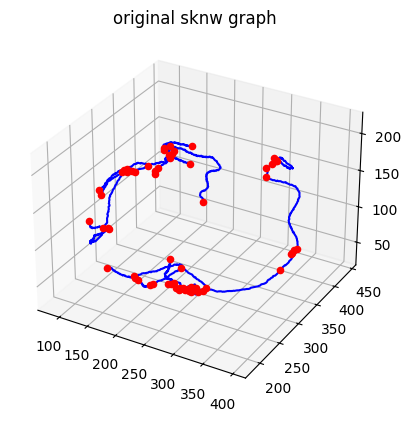

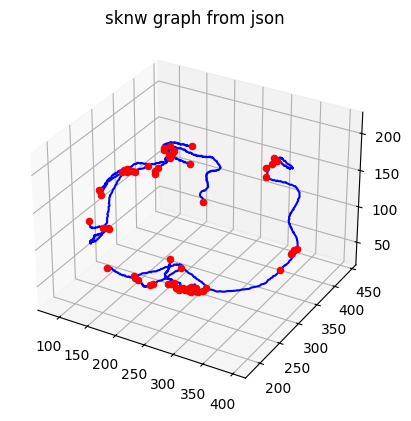

In [165]:
# okay cool this works.

# now we need is to make sure that the profs can load the networkx graph from the json file.
# let's create a graph from snkw_json
snkw_graph_from_json = nx.node_link_graph(snkw_json, directed=False, multigraph=False, edges="edges")

# let's plot it
plot_networkx_graph(snkw_graph, title="original sknw graph")
plot_networkx_graph(snkw_graph_from_json, title="sknw graph from json")

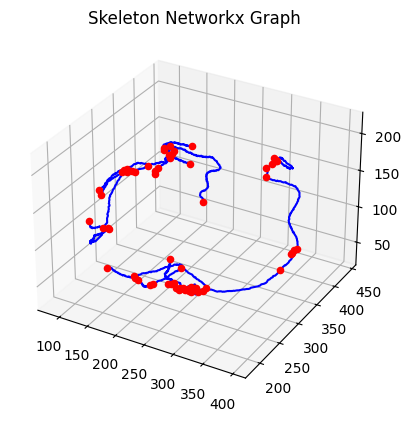

In [166]:
import nibabel as nib
from skimage.morphology import skeletonize
import sknw
import matplotlib.pyplot as plt

def plot_networkx_graph(graph_data, title):
    plt.figure()
    ax = plt.subplot(111, projection='3d')

    for node_id in graph_data.nodes:
        pos = graph_data.nodes[node_id]['pts'][0].tolist()
        ax.scatter(pos[0], pos[1], pos[2], c='r')
    
    for (s, e) in graph_data.edges():
        ps = graph_data[s][e]['pts']
        ax.plot(ps[:, 0], ps[:, 1], ps[:, 2], c='b')

    plt.title(title)
    plt.show()

# replace with your own file paths
label_graph_folder = Path("label_graph/")
label_fp = label_graph_folder / "00328c.label.nii.gz"

mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

skeleton = skeletonize(ras_mask_matrice)
snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)
plot_networkx_graph(snkw_graph, "Skeleton Networkx Graph")
